# CatBoost House Price Prediction – Model Training & Evaluation

This notebook starts **after the group preprocessing pipeline**.

The preprocessing notebook already:
- split the original dataset into training and testing sets,
- fitted scaling and encoding using the training data,
- transformed both sets,
- saved `final_train_processed_house_data.csv`,
- saved `final_test_processed_house_data.csv`.

Therefore, **no preprocessing, scaling, encoding, missing-value handling, duplicate removal, or new train/test split is done here**.

**Target:** `price`  
**Model:** `CatBoostRegressor`

In [2]:
# Install CatBoost in Google Colab
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [3]:
# Import libraries used for model training and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Upload the already processed datasets

Upload the **two output files created by the preprocessing notebook**:

1. `final_train_processed_house_data.csv`
2. `final_test_processed_house_data.csv`

We use them directly because preprocessing has already been completed.

In [4]:
# Load the already-preprocessed train and test files
train_df = pd.read_csv('/content/final_train_processed_house_data.csv')
test_df = pd.read_csv('/content/final_test_processed_house_data (1).csv')

print("Processed datasets loaded successfully!")
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

display(train_df.head())

Processed datasets loaded successfully!
Training dataset shape: (17290, 93)
Testing dataset shape : (4323, 93)


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,...,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,price
0,-0.395263,-0.474451,-0.919600,0,0,4,9,-0.656310,0.404001,-1.396608,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,325000.0
1,-1.468964,-1.452583,-0.919600,0,0,3,6,-0.200433,-1.430565,-0.060172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,257000.0
2,-0.395263,-1.452583,0.001545,0,0,3,6,-0.451165,-0.988910,-0.552847,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228500.0
3,-0.395263,0.177636,-0.919600,0,0,4,7,1.189993,0.200160,-1.193614,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,288000.0
4,-1.468964,0.503680,0.922690,0,0,3,8,0.016109,1.219364,1.040039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,479000.0


## 2. Separate predictors and target

The preprocessing pipeline already created the train/test split.  
Here we only separate the `price` target from the processed predictor columns.

In [5]:
X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

# Keep exactly the same feature order in the test set
X_test = X_test.reindex(columns=X_train.columns)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Train/test columns identical:", X_train.columns.equals(X_test.columns))

X_train: (17290, 92)
y_train: (17290,)
X_test : (4323, 92)
y_test : (4323,)
Train/test columns identical: True


## 3. Evaluation function

Because house price prediction is a **regression problem**, the model is evaluated using:

- **MAE** – average absolute prediction error.
- **MSE** – average squared prediction error.
- **RMSE** – prediction error in the same unit as house price.
- **R²** – how much variation in house prices is explained by the model.

Lower MAE/RMSE is better. Higher R² is better.

In [6]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    return {
        'Model': name,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'R2 Gap': train_r2 - test_r2
    }

## 4. Train a baseline CatBoost model

This gives us a starting result before tuning.

`random_seed=42` makes the experiment reproducible.  
`verbose=0` prevents CatBoost from printing every training iteration.

In [7]:
baseline_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=42,
    verbose=0
)

baseline_model.fit(X_train, y_train)

print("Baseline CatBoost model trained successfully!")

Baseline CatBoost model trained successfully!


In [8]:
baseline_result = evaluate_model(
    'Baseline',
    baseline_model,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([baseline_result]).round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
0,Baseline,56882.9351,68148.3777,85878.8994,128168.7751,0.9435,0.8913,0.0522


## CatBoost Model Variations

The same CatBoost regression algorithm is trained using four different hyperparameter settings:

- **V1 - Baseline:** Starting model with lower depth and fewer iterations.
- **V2 - Increased Complexity:** Uses more iterations and deeper trees than the baseline.
- **V3 - Regularized:** Uses a lower learning rate and stronger L2 regularization.
- **V4 - Deep CatBoost:** Uses the deepest trees among the four variations with L2 regularization.

The models are compared using **Train R², Test R², Train RMSE, and Test RMSE**. The final model should be selected mainly using its performance on the unseen test set while also checking the train-test gap.


## 5. Manual hyperparameter tuning

To satisfy the requirement to train **different varieties of the same model**, four CatBoost versions are tested.

We change:
- `iterations` – number of boosting rounds,
- `depth` – depth of each tree,
- `learning_rate` – how strongly each new tree updates the model,
- `l2_leaf_reg` – L2 regularization used to control model complexity.

In [9]:
catboost_variations = {
    'V1 - Baseline': {
        'iterations': 300,
        'depth': 4,
        'learning_rate': 0.05,
        'l2_leaf_reg': 3
    },
    'V2 - Increased Complexity': {
        'iterations': 500,
        'depth': 6,
        'learning_rate': 0.05,
        'l2_leaf_reg': 3
    },
    'V3 - Regularized': {
        'iterations': 700,
        'depth': 6,
        'learning_rate': 0.03,
        'l2_leaf_reg': 5
    },
    'V4 - Deep CatBoost': {
        'iterations': 500,
        'depth': 8,
        'learning_rate': 0.05,
        'l2_leaf_reg': 5
    }
}

manual_results = []
manual_models = {}

for name, params in catboost_variations.items():
    model = CatBoostRegressor(
        **params,
        loss_function='RMSE',
        random_seed=42,
        verbose=0
    )

    model.fit(X_train, y_train)
    manual_models[name] = model

    result = evaluate_model(
        name, model,
        X_train, y_train,
        X_test, y_test
    )

    manual_results.append(result)

manual_results_df = pd.DataFrame(manual_results)
manual_results_df.round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
0,V1 - Baseline,68291.1323,76449.1355,107396.6107,143539.9978,0.9117,0.8637,0.0480
1,V2 - Increased Complexity,56882.9351,68148.3777,85878.8994,128168.7751,0.9435,0.8913,0.0522
2,V3 - Regularized,59853.7015,69683.0192,91913.3648,128434.2081,0.9353,0.8909,0.0445
3,V4 - Deep CatBoost,53104.0499,66459.4261,78764.8823,123375.7111,0.9525,0.8993,0.0532


In [10]:
# Training vs Testing comparison for all CatBoost variations

comparison_table = manual_results_df[
    ['Model', 'Train R2', 'Test R2', 'Train RMSE', 'Test RMSE']
].copy()

comparison_table['R2 Gap'] = (
    comparison_table['Train R2'] - comparison_table['Test R2']
)

comparison_table['RMSE Gap'] = (
    comparison_table['Test RMSE'] - comparison_table['Train RMSE']
)

print("CatBoost Training vs Testing Performance")
display(comparison_table.round(4))


CatBoost Training vs Testing Performance


,Model,Train R2,Test R2,Train RMSE,Test RMSE,R2 Gap,RMSE Gap
0,V1 - Baseline,0.9117,0.8637,107396.6107,143539.9978,0.0480,36143.3871
1,V2 - Increased Complexity,0.9435,0.8913,85878.8994,128168.7751,0.0522,42289.8757
2,V3 - Regularized,0.9353,0.8909,91913.3648,128434.2081,0.0445,36520.8434
3,V4 - Deep CatBoost,0.9525,0.8993,78764.8823,123375.7111,0.0532,44610.8288


## 6. Compare the manually tuned models

The main final comparison should focus on **test RMSE** and **test R²**, because the test set represents unseen data.

A very large difference between training and testing performance can indicate overfitting.

In [11]:
manual_results_df.sort_values('Test RMSE').round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
3,V4 - Deep CatBoost,53104.0499,66459.4261,78764.8823,123375.7111,0.9525,0.8993,0.0532
1,V2 - Increased Complexity,56882.9351,68148.3777,85878.8994,128168.7751,0.9435,0.8913,0.0522
2,V3 - Regularized,59853.7015,69683.0192,91913.3648,128434.2081,0.9353,0.8909,0.0445
0,V1 - Baseline,68291.1323,76449.1355,107396.6107,143539.9978,0.9117,0.8637,0.0480


In [12]:
best_manual_name = manual_results_df.loc[
    manual_results_df['Test RMSE'].idxmin(), 'Model'
]

best_manual_model = manual_models[best_manual_name]

print("Best manually tuned model:", best_manual_name)
print("Parameters:", best_manual_model.get_params())

Best manually tuned model: V4 - Deep CatBoost
Parameters: {'iterations': 500, 'learning_rate': 0.05, 'depth': 8, 'l2_leaf_reg': 5, 'loss_function': 'RMSE', 'random_seed': 42, 'verbose': 0}


## 7. Visual comparison of CatBoost variations

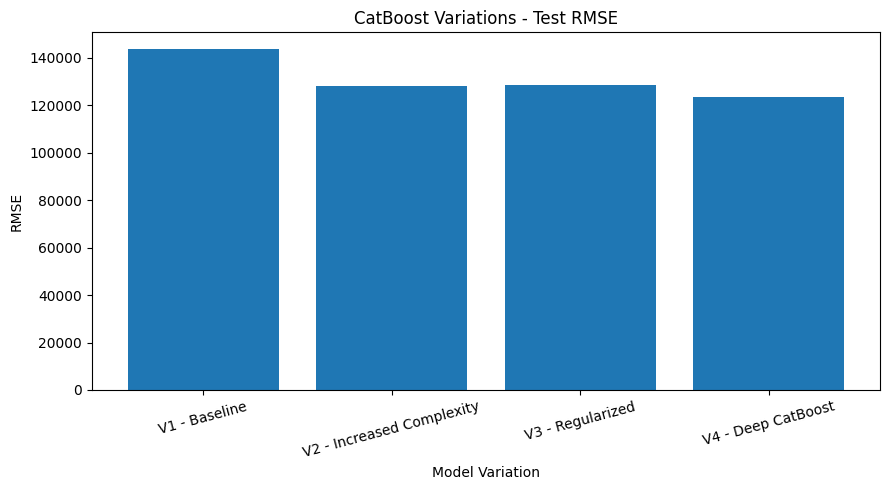

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(manual_results_df['Model'], manual_results_df['Test RMSE'])
plt.title('CatBoost Variations - Test RMSE')
plt.xlabel('Model Variation')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

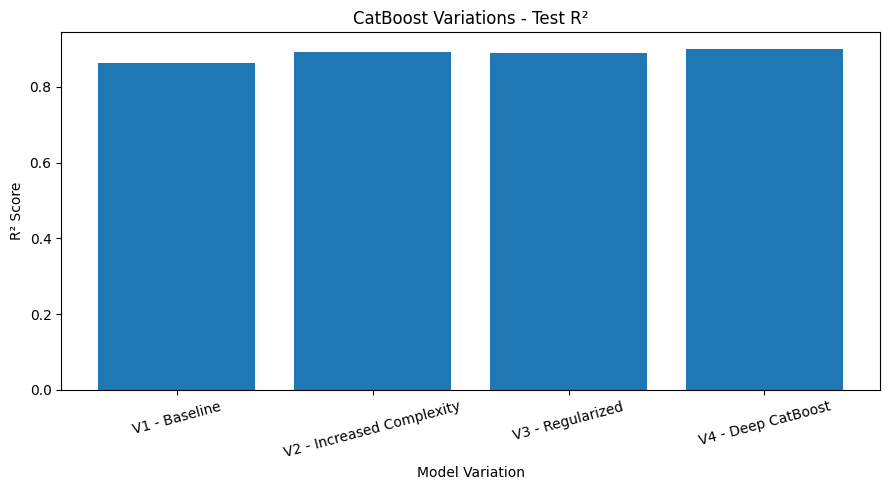

In [14]:
plt.figure(figsize=(9, 5))
plt.bar(manual_results_df['Model'], manual_results_df['Test R2'])
plt.title('CatBoost Variations - Test R²')
plt.xlabel('Model Variation')
plt.ylabel('R² Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. GridSearchCV parameter tuning

GridSearchCV systematically tests combinations of hyperparameters.

**Important:** GridSearchCV is applied only to the processed **training set**.  
The final test set is kept separate and is used only after tuning.

`cv=3` means the training data is divided into 3 folds during cross-validation.

In [15]:
grid_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0
)

param_grid = {
    'iterations': [300, 500],
    'depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 5]
}

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("GridSearchCV completed!")
print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
GridSearchCV completed!
Best parameters: {'depth': 6, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Best CV RMSE: 114794.63513001578


## 9. Evaluate the best GridSearchCV model on the untouched test set

In [16]:
best_grid_model = grid_search.best_estimator_

grid_result = evaluate_model(
    'GridSearch Best',
    best_grid_model,
    X_train, y_train,
    X_test, y_test
)

pd.DataFrame([grid_result]).round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
0,GridSearch Best,56882.9351,68148.3777,85878.8994,128168.7751,0.9435,0.8913,0.0522


## 10. Final model comparison

In [17]:
# Combine the 4 manual CatBoost variations + GridSearch best model
all_results = pd.concat(
    [
        manual_results_df,              # V1, V2, V3, V4
        pd.DataFrame([grid_result])      # GridSearch Best
    ],
    ignore_index=True
)

# Sort models by Test RMSE
# Lower RMSE = better
all_results = all_results.sort_values(
    'Test RMSE'
).reset_index(drop=True)

# Display the final comparison table
display(all_results.round(4))

# Select the best model
best_model_name = all_results.loc[0, 'Model']

print("\nBest model based on lowest Test RMSE:", best_model_name)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2 Gap
0,V4 - Deep CatBoost,53104.0499,66459.4261,78764.8823,123375.7111,0.9525,0.8993,0.0532
1,V2 - Increased Complexity,56882.9351,68148.3777,85878.8994,128168.7751,0.9435,0.8913,0.0522
2,GridSearch Best,56882.9351,68148.3777,85878.8994,128168.7751,0.9435,0.8913,0.0522
3,V3 - Regularized,59853.7015,69683.0192,91913.3648,128434.2081,0.9353,0.8909,0.0445
4,V1 - Baseline,68291.1323,76449.1355,107396.6107,143539.9978,0.9117,0.8637,0.0480



Best model based on lowest Test RMSE: V4 - Deep CatBoost


## 11. Select the final CatBoost model

In [18]:
if best_model_name == 'Baseline':
    final_model = baseline_model
elif best_model_name == 'GridSearch Best':
    final_model = best_grid_model
else:
    final_model = manual_models[best_model_name]

final_predictions = final_model.predict(X_test)

print("Final selected model:", best_model_name)

Final selected model: V4 - Deep CatBoost


## 12. Actual vs Predicted house prices

If the model predicts well, the points should stay reasonably close to the diagonal reference line.

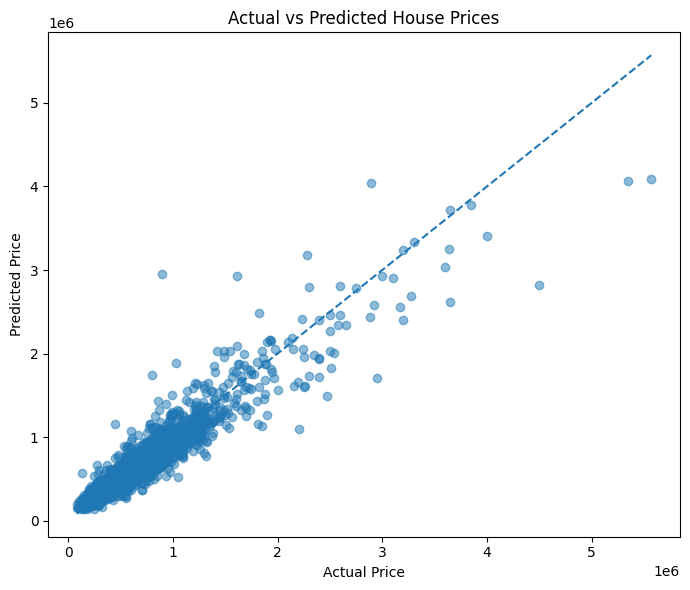

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_predictions, alpha=0.5)

minimum = min(y_test.min(), final_predictions.min())
maximum = max(y_test.max(), final_predictions.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle='--')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

## 13. Residual plot

Residual = Actual Price − Predicted Price.

A useful model should have residuals distributed around zero without a strong systematic pattern.

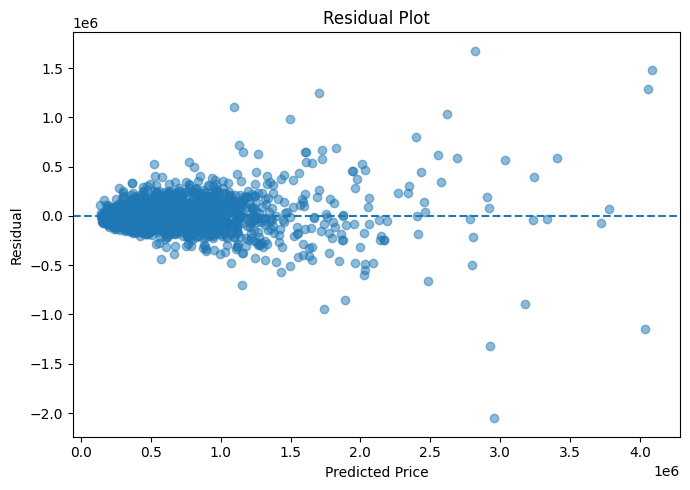

In [20]:
residuals = y_test - final_predictions

plt.figure(figsize=(7, 5))
plt.scatter(final_predictions, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 14. Feature importance

CatBoost provides feature importance values showing which processed input features contributed most to the model.

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': final_model.get_feature_importance()
}).sort_values('Importance', ascending=False)

display(feature_importance.head(15))

,Feature,Importance
9,lat,30.562160
18,sqft_living_log,15.264694
6,grade,13.030705
10,long,12.035759
11,sqft_living15,4.130749
20,sqft_above_log,3.839401
3,waterfront,3.672107
4,view,3.161968
14,house_age,2.334275
25,zipcode_98004,1.700177


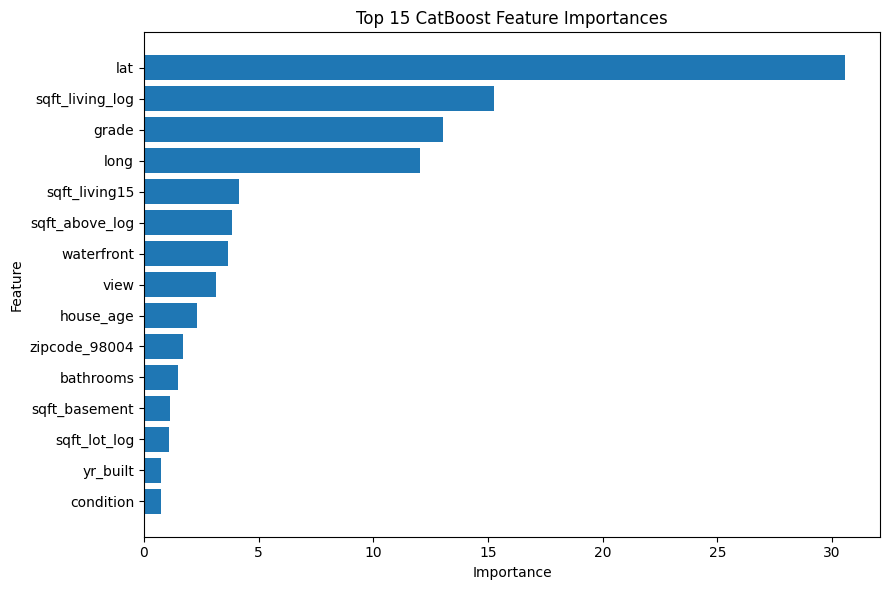

In [22]:
top_features = feature_importance.head(15).sort_values('Importance')

plt.figure(figsize=(9, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 CatBoost Feature Importances')
plt.tight_layout()
plt.show()

## 15. Final evaluation summary

Use the output generated below when explaining your model in the viva.

In [23]:
final_mae = mean_absolute_error(y_test, final_predictions)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_predictions)

print("FINAL CATBOOST MODEL")
print("--------------------")
print("Selected variation :", best_model_name)
print(f"MAE  : {final_mae:.2f}")
print(f"MSE  : {final_mse:.2f}")
print(f"RMSE : {final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

FINAL CATBOOST MODEL
--------------------
Selected variation : V4 - Deep CatBoost
MAE  : 66459.43
MSE  : 15221566078.01
RMSE : 123375.71
R²   : 0.8993


# Viva points

### Why CatBoost?
CatBoost is a gradient boosting algorithm based on decision trees. It can learn complex and non-linear relationships between house characteristics and house prices, so it is suitable for this regression problem.

### Did I preprocess the data again?
No. The group preprocessing pipeline had already completed feature engineering, train/test splitting, scaling and encoding. This notebook loads the final processed training and testing files directly.

### Why did I not split the data again?
The preprocessing pipeline already created a leakage-safe train/test split. Splitting the final test file again would change the original pipeline and would not use the intended held-out test set.

### How did I tune the model?
I used two approaches:
1. Manual tuning with four CatBoost parameter combinations.
2. GridSearchCV with 3-fold cross-validation on the training set.

### Why use MAE?
MAE shows the average absolute difference between actual and predicted house prices.

### Why use RMSE?
RMSE gives more penalty to large prediction errors and is expressed in the same unit as the target price.

### Why use R²?
R² shows how much of the variation in house prices is explained by the model. A value closer to 1 indicates stronger predictive performance.

### How did I check overfitting?
I compared training and testing performance. If training R² is much higher than test R², or test error is much larger than training error, the model may be overfitting.

### How was the final model selected?
The model varieties were compared mainly using test RMSE and test R². The final model was selected based on its performance on unseen test data while also considering the train-test performance gap.

### Limitation
House prices are influenced by factors that may not be fully represented in the available dataset. Model performance also depends on the selected features and hyperparameters.

### Possible improvement
Future work can test a wider hyperparameter search, additional useful features, and stronger validation strategies.